In [3]:
import pandas as pd
df = pd.read_csv("/content/OnlineRetail.csv", encoding='latin1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [9]:
display(df.describe())

,Quantity,UnitPrice,CustomerID
count,536641.000000,536641.000000,401604.000000
mean,9.620029,4.632656,15281.160818
std,219.130156,97.233118,1714.006089
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13939.000000
50%,3.000000,2.080000,15145.000000
75%,10.000000,4.130000,16784.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
print(df.shape)

df.info()

(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
print("Missing Values\n")

print(df.isnull().sum())

Missing Values

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [7]:
print(df.isnull().sum())


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [8]:
print("Duplicate Rows :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After Removal :", df.shape)

Duplicate Rows : 5268
After Removal : (536641, 8)


In [10]:
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_quantity = df[
    (df["Quantity"] < lower) |
    (df["Quantity"] > upper)
]

print("Outliers in Quantity column:")
display(outliers_quantity.head())

Outliers in Quantity column:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,12/1/2010 8:45,3.75,12583.0,France
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,12/1/2010 8:45,3.75,12583.0,France
30,536370,21883,STARS GIFT TAPE,24,12/1/2010 8:45,0.65,12583.0,France
31,536370,10002,INFLATABLE POLITICAL GLOBE,48,12/1/2010 8:45,0.85,12583.0,France


In [14]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

print("DataFrame shape after removing non-positive Quantity and UnitPrice:", df.shape)
print("Summary statistics after cleaning:")
display(df.describe())

DataFrame shape after removing non-positive Quantity and UnitPrice: (524878, 8)
Summary statistics after cleaning:


,Quantity,UnitPrice,CustomerID
count,524878.000000,524878.000000,392692.000000
mean,10.616600,3.922573,15287.843865
std,156.280031,36.093028,1713.539549
min,1.000000,0.001000,12346.000000
25%,1.000000,1.250000,13955.000000
50%,4.000000,2.080000,15150.000000
75%,11.000000,4.130000,16791.000000
max,80995.000000,13541.330000,18287.000000


In [15]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    524878 non-null  object 
 1   StockCode    524878 non-null  object 
 2   Description  524878 non-null  object 
 3   Quantity     524878 non-null  int64  
 4   InvoiceDate  524878 non-null  object 
 5   UnitPrice    524878 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      524878 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 36.0+ MB
None


In [16]:
print("Missing Values after initial cleaning:\n", df.isnull().sum())

Missing Values after initial cleaning:
 InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
dtype: int64


In [26]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

numeric_cols_retail = ['Quantity', 'UnitPrice']
categorical_cols_retail = ['Country']

scaler = MinMaxScaler()
df[numeric_cols_retail] = scaler.fit_transform(df[numeric_cols_retail])

print("Scaled numeric columns (Quantity, UnitPrice):")
display(df[numeric_cols_retail].head())

Scaled numeric columns (Quantity, UnitPrice):


,Quantity,UnitPrice
0,0.000062,0.000313
1,0.000062,0.000416
2,0.000086,0.000338
3,0.000062,0.000416
4,0.000062,0.000416


In [27]:
for col in categorical_cols_retail:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    print(f"Encoded categorical column: {col}")
    display(df[[col]].head())


Encoded categorical column: Country


,Country
0,35
1,35
2,35
3,35
4,35


In [28]:
print("Final DataFrame info after all preprocessing steps:")
print(df.info())
print("Final DataFrame head:")
display(df.head())

Final DataFrame info after all preprocessing steps:
<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  float64       
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 27.0+ MB
None
Final DataFrame head:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,0.000062,2010-12-01 08:26:00,0.000313,17850.0,35
1,536365,71053,WHITE METAL LANTERN,0.000062,2010-12-01 08:26:00,0.000416,17850.0,35
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,0.000086,2010-12-01 08:26:00,0.000338,17850.0,35
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,0.000062,2010-12-01 08:26:00,0.000416,17850.0,35
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,0.000062,2010-12-01 08:26:00,0.000416,17850.0,35


In [30]:
df.to_csv("cleaned_online_retail_dataset.csv", index=False)
print("Cleaned Online Retail dataset saved successfully as 'cleaned_online_retail_dataset.csv'.")

Cleaned Online Retail dataset saved successfully as 'cleaned_online_retail_dataset.csv'.


In [29]:
df.to_csv("cleaned_online_retail_dataset.csv", index=False)
print("Cleaned Online Retail dataset saved successfully as 'cleaned_online_retail_dataset.csv'.")

Cleaned Online Retail dataset saved successfully as 'cleaned_online_retail_dataset.csv'.


In [23]:
df.dropna(subset=['CustomerID'], inplace=True)
print("Shape after dropping rows with missing CustomerID:", df.shape)

Shape after dropping rows with missing CustomerID: (392692, 8)


In [24]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("InvoiceDate column converted to datetime.")

InvoiceDate column converted to datetime.


In [25]:
print(df.info())
print("Missing Values after cleaning and type conversion:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  float64       
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 27.0+ MB
None
Missing Values after cleaning and type conversion:
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


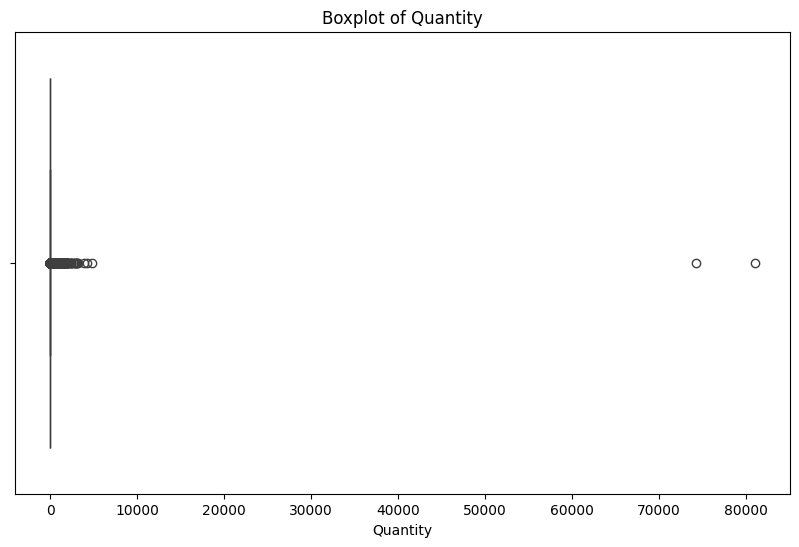

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Quantity'])
plt.title('Boxplot of Quantity')
plt.xlabel('Quantity')
plt.show()